<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day4_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Si tu as un compte Kaggle avec une clé API
from google.colab import files
files.upload()  # Upload ton fichier kaggle.json

import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

!kaggle datasets download -d vivek468/superstore-dataset-final
!unzip superstore-dataset-final.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
License(s): other
100% 550k/550k [00:00<00:00, 119MB/s]

Archive:  superstore-dataset-final.zip
  inflating: Sample - Superstore.csv  


In [2]:
# ============================================================
# CHARGEMENT ET EXPLORATION INITIALE DU SUPERSTORE DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, Dropdown, IntSlider

df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')

print("=== Aperçu des données ===")
print(df.head())

print(f"\n{df.shape[0]} lignes, {df.shape[1]} colonnes")

print("\n=== Colonnes ===")
print(df.columns.tolist())

print("\n=== Types de données ===")
print(df.dtypes)

print("\n=== Valeurs manquantes (en %) ===")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\n=== Statistiques descriptives ===")
print(df.describe())

=== Aperçu des données ===
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Categ

In [3]:
# ============================================================
# ÉTAPE 1 : Nettoyage et Feature Engineering
# ============================================================

# ------------------------------------------------------------
# 1) Conversion des dates
# ------------------------------------------------------------
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

print("=== Dates converties ===")
print(f"Période couverte : {df['Order Date'].min().date()} à {df['Order Date'].max().date()}")

# ------------------------------------------------------------
# 2) Feature Engineering
# ------------------------------------------------------------
# Profit Margin : mesure la rentabilité relative (pas juste absolue)
# Utile pour comparer des produits à des prix très différents
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Variables temporelles pour les analyses de tendances
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

print("\n=== Nouvelles features créées ===")
print(df[['Order Date', 'Sales', 'Profit', 'Profit Margin',
          'Order Year', 'Order Month']].head())

print("\n=== Années disponibles ===")
print(sorted(df['Order Year'].unique()))

print("\n=== Catégories disponibles ===")
print(df['Category'].unique())

print("\n=== Segments disponibles ===")
print(df['Segment'].unique())

print("\n=== Statistiques Profit Margin ===")
print(df['Profit Margin'].describe())

# Vérification : combien de transactions sont en perte ?
loss_count = (df['Profit'] < 0).sum()
print(f"\nTransactions en perte : {loss_count} ({loss_count/len(df)*100:.1f}%)")

=== Dates converties ===
Période couverte : 2014-01-03 à 2017-12-30

=== Nouvelles features créées ===
  Order Date     Sales    Profit  Profit Margin  Order Year  Order Month
0 2016-11-08  261.9600   41.9136          16.00        2016           11
1 2016-11-08  731.9400  219.5820          30.00        2016           11
2 2016-06-12   14.6200    6.8714          47.00        2016            6
3 2015-10-11  957.5775 -383.0310         -40.00        2015           10
4 2015-10-11   22.3680    2.5164          11.25        2015           10

=== Années disponibles ===
[np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]

=== Catégories disponibles ===
['Furniture' 'Office Supplies' 'Technology']

=== Segments disponibles ===
['Consumer' 'Corporate' 'Home Office']

=== Statistiques Profit Margin ===
count    9994.000000
mean       12.031393
std        46.675435
min      -275.000000
25%         7.500000
50%        27.000000
75%        36.250000
max        50.000000
Name: Profit Mar

In [4]:
# ============================================================
# ÉTAPE 2 : EDA Interactive
# ============================================================

from ipywidgets import interact, Dropdown, IntSlider
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# ------------------------------------------------------------
# Préparation des données temporelles
# ------------------------------------------------------------
monthly_sales = df.groupby(
    ['Order Month-Year', 'Category']
)['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

# Données géographiques
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

# ============================================================
# GRAPHIQUE 1 : Time Series interactif par catégorie
# ============================================================
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(
            total_monthly.index.to_timestamp(),
            total_monthly.values,
            marker='o', linewidth=2, markersize=4, color='steelblue'
        )
        plt.title('Monthly Sales Trend — All Categories',
                  fontsize=16, fontweight='bold')
    else:
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(
            category_data['Date'],
            category_data['Sales'],
            marker='o', linewidth=2, markersize=4, color='darkorange'
        )
        plt.title(f'Monthly Sales Trend — {category}',
                  fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Statistiques affichées sous le graphique
    if category == 'All':
        data = df.groupby('Order Month-Year')['Sales'].sum()
    else:
        data = monthly_sales[
            monthly_sales['Category'] == category
        ].set_index('Date')['Sales']

    print(f"Ventes moyennes mensuelles : ${data.mean():,.0f}")
    print(f"Meilleur mois             : ${data.max():,.0f}")
    print(f"Moins bon mois            : ${data.min():,.0f}")

# Widget Dropdown
categories = ['All'] + list(df['Category'].unique())
category_dropdown = Dropdown(
    options=categories,
    value='All',
    description='Category:'
)
interact(plot_monthly_sales, category=category_dropdown)

# ============================================================
# GRAPHIQUE 2 : Top N États par ventes (horizontal bar interactif)
# ============================================================
def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))

    top_states = state_sales.tail(top_n)

    bars = plt.barh(
        range(len(top_states)),
        top_states.values,
        color='steelblue', edgecolor='white'
    )
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance',
              fontsize=16, fontweight='bold')

    # Annotations sur chaque barre
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(
            value + max(top_states.values) * 0.01, i,
            f'${value:,.0f}',
            va='center', fontsize=9
        )

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Nombre total d'états analysés : {len(state_sales)}")
    print(f"Top {top_n} états représentent : ${top_states.sum():,.0f} en ventes")
    print(f"Part du total : {top_states.sum()/state_sales.sum()*100:.1f}%")

# Widget Slider
top_n_slider = IntSlider(
    min=5, max=25, value=10,
    description='Top N States:'
)
interact(plot_top_states, top_n=top_n_slider)

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

<function __main__.plot_top_states(top_n=10)>

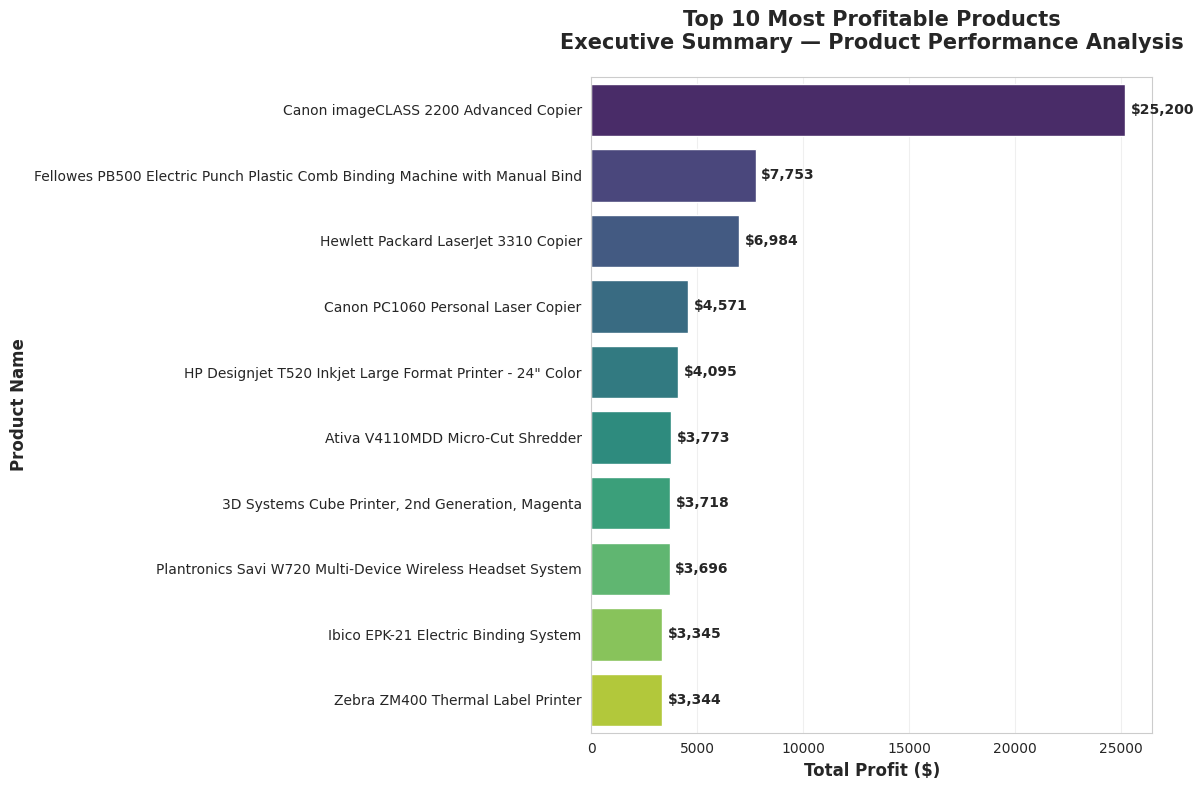

=== Key Insights — Top 10 Products ===
Most profitable product : $25,200
Top 10 total profit     : $66,479
Average profit (top 10) : $6,648


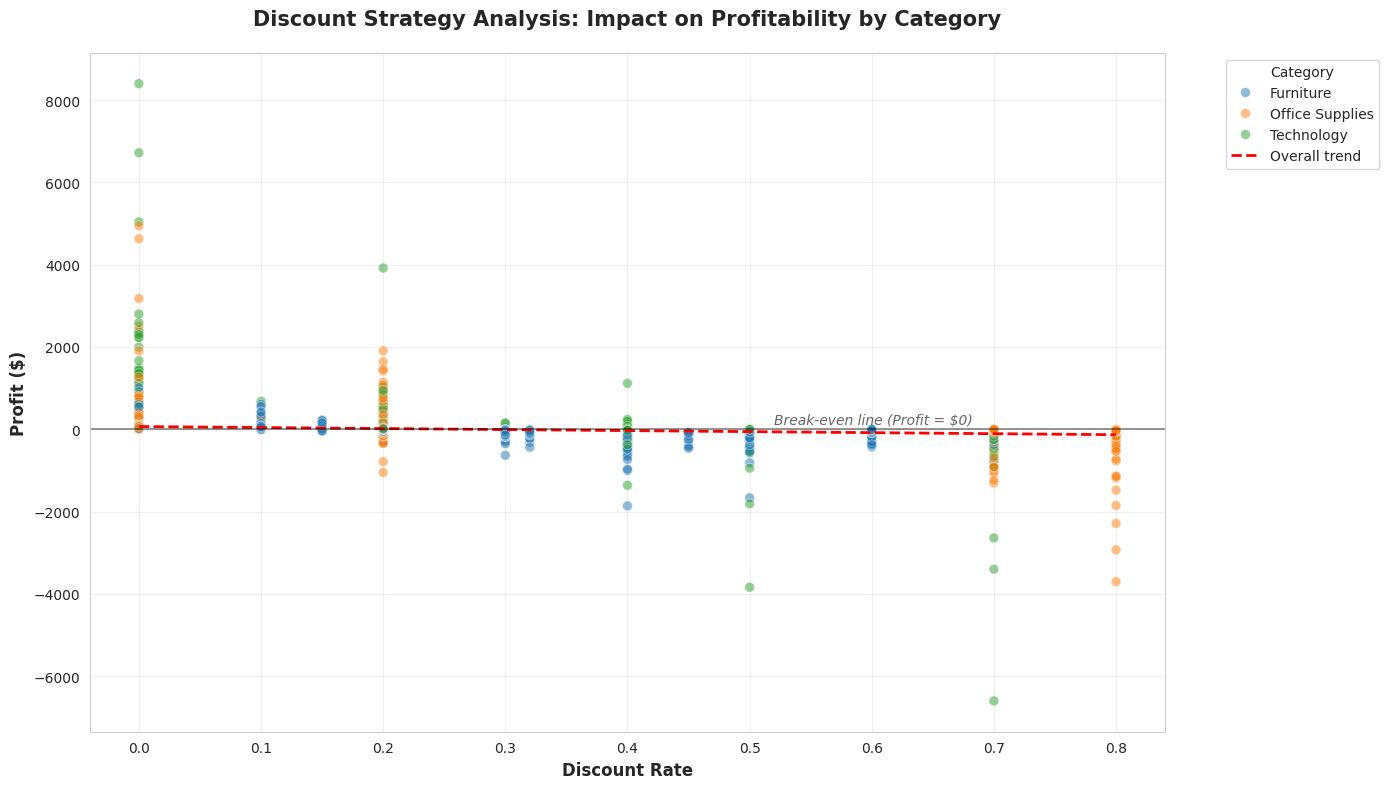


=== Discount Analysis Insights ===
Transactions avec remise > 20%         : 1,393
Profit moyen (remise > 20%)            : $-97.18
% en perte parmi remises > 20%         : 96.8%

=== Impact par catégorie (remise > 20%) ===
Furniture            → profit moyen : $ -100.51 | % en perte : 97.2%
Office Supplies      → profit moyen : $  -69.32 | % en perte : 100.0%
Technology           → profit moyen : $ -197.42 | % en perte : 82.5%


In [5]:
# ============================================================
# ÉTAPE 3 : Visualisations Seaborn
# ============================================================

fig_width = 14

# ============================================================
# GRAPHIQUE 1 : Top 10 produits les plus rentables
# ============================================================
product_profit = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=product_profit.values,
    y=product_profit.index,
    hue=product_profit.index,
    palette='viridis',
    orient='h',
    legend=False
)

plt.title(
    'Top 10 Most Profitable Products\nExecutive Summary — Product Performance Analysis',
    fontsize=15, fontweight='bold', pad=20
)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

# Annotations : valeur exacte au bout de chaque barre
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(
        profit + max(product_profit.values) * 0.01, i,
        f'${profit:,.0f}',
        va='center', fontweight='bold', fontsize=10
    )

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Key Insights — Top 10 Products ===")
print(f"Most profitable product : ${product_profit.iloc[0]:,.0f}")
print(f"Top 10 total profit     : ${product_profit.sum():,.0f}")
print(f"Average profit (top 10) : ${product_profit.mean():,.0f}")

# ============================================================
# GRAPHIQUE 2 : Discount vs Profit — scatter + régression
# ============================================================
plt.figure(figsize=(14, 8))

# Scatter plot avec couleur par catégorie
sns.scatterplot(
    data=df,
    x='Discount', y='Profit',
    hue='Category',
    alpha=0.5, s=50
)

# Ligne de régression globale (tendance générale toutes catégories)
sns.regplot(
    data=df,
    x='Discount', y='Profit',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    label='Overall trend'
)

# Ligne break-even (profit = 0)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1.5)
plt.text(0.52, 120, 'Break-even line (Profit = $0)',
         fontsize=10, alpha=0.7, fontstyle='italic')

plt.title(
    'Discount Strategy Analysis: Impact on Profitability by Category',
    fontsize=15, fontweight='bold', pad=20
)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyse chiffrée des remises
print("\n=== Discount Analysis Insights ===")
high_discount = df[df['Discount'] > 0.2]
print(f"Transactions avec remise > 20%         : {len(high_discount):,}")
print(f"Profit moyen (remise > 20%)            : ${high_discount['Profit'].mean():.2f}")
print(f"% en perte parmi remises > 20%         : {(high_discount['Profit'] < 0).mean()*100:.1f}%")

print("\n=== Impact par catégorie (remise > 20%) ===")
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc) > 0:
        avg_profit = high_disc['Profit'].mean()
        pct_loss = (high_disc['Profit'] < 0).mean() * 100
        print(f"{category:20s} → profit moyen : ${avg_profit:8.2f} | % en perte : {pct_loss:.1f}%")

       MATPLOTLIB vs SEABORN — ÉVALUATION COMPARATIVE

⏱️  Vitesse d'exécution :
   Matplotlib : 0.0374 secondes
   Seaborn    : 0.0703 secondes

📊 MATPLOTLIB — Points forts (observés dans notre analyse) :
   • Contrôle précis sur chaque élément visuel (taille, position, couleur)
   • Intégration native avec ipywidgets pour l'interactivité
   • Annotations et texte positionnés manuellement avec précision
   • Idéal pour des dashboards complexes multi-subplots (plt.subplots)
   • Référence incontournable : Seaborn et Pandas Plot sont built ON TOP de Matplotlib

📈 SEABORN — Points forts (observés dans notre analyse) :
   • Syntaxe orientée DataFrame (data=df, x='col', hue='col') — très concise
   • Palettes et styles professionnels prêts à l'emploi (viridis, Set2...)
   • Visualisations statistiques intégrées (regplot, boxplot avec stats, etc.)
   • Gestion automatique des légendes et des couleurs par catégorie
   • Résultats publication-ready en beaucoup moins de lignes de code

🎯 RECOM

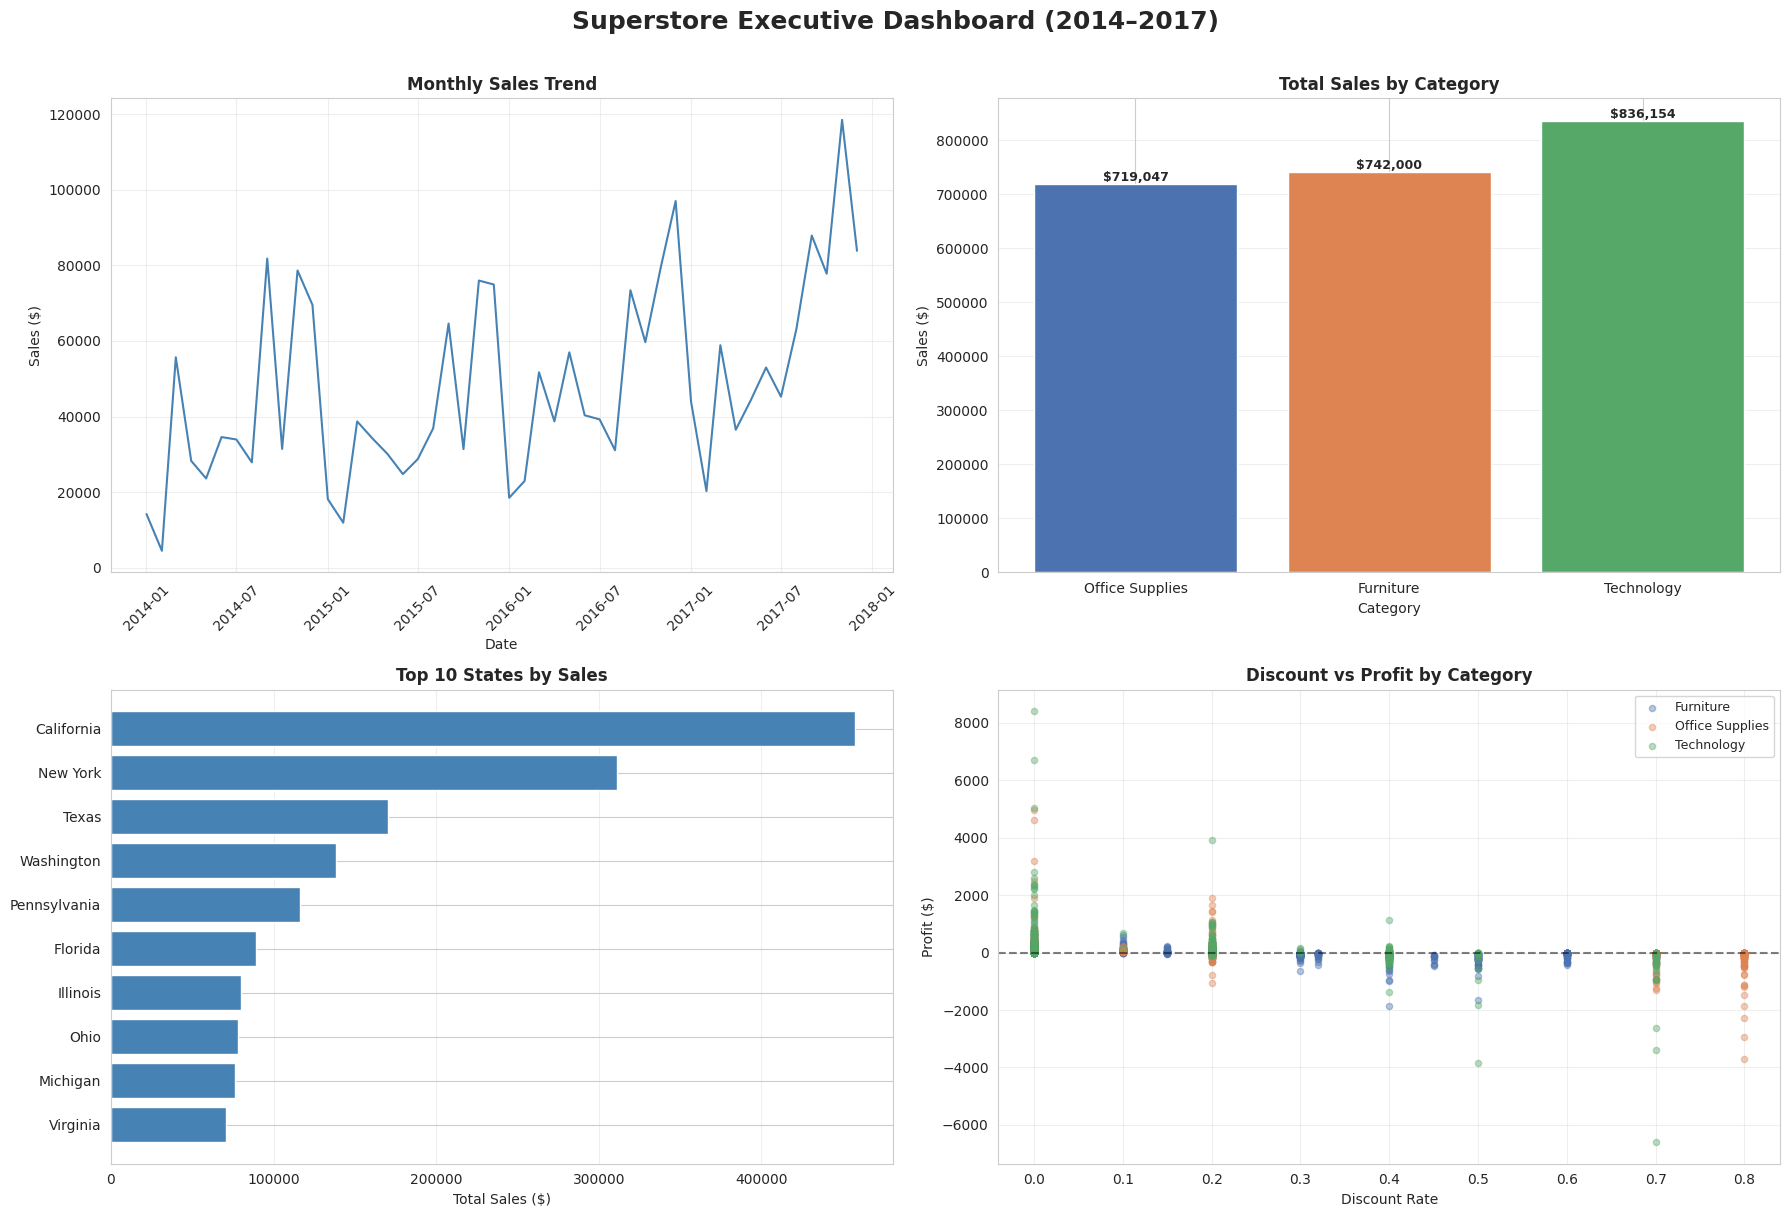

In [6]:
# ============================================================
# ÉTAPE 4A : Comparaison Matplotlib vs Seaborn
# ============================================================

import time

print("=" * 55)
print("       MATPLOTLIB vs SEABORN — ÉVALUATION COMPARATIVE")
print("=" * 55)

# --- Benchmark de vitesse ---
# Matplotlib
start = time.time()
plt.figure(figsize=(8, 5))
yearly = df.groupby('Order Year')['Sales'].sum()
plt.plot(yearly.index, yearly.values)
plt.close()
matplotlib_time = time.time() - start

# Seaborn
start = time.time()
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df.groupby('Order Year')['Sales'].sum().reset_index(),
    x='Order Year', y='Sales'
)
plt.close()
seaborn_time = time.time() - start

print(f"\n⏱️  Vitesse d'exécution :")
print(f"   Matplotlib : {matplotlib_time:.4f} secondes")
print(f"   Seaborn    : {seaborn_time:.4f} secondes")

print("""
📊 MATPLOTLIB — Points forts (observés dans notre analyse) :
   • Contrôle précis sur chaque élément visuel (taille, position, couleur)
   • Intégration native avec ipywidgets pour l'interactivité
   • Annotations et texte positionnés manuellement avec précision
   • Idéal pour des dashboards complexes multi-subplots (plt.subplots)
   • Référence incontournable : Seaborn et Pandas Plot sont built ON TOP de Matplotlib

📈 SEABORN — Points forts (observés dans notre analyse) :
   • Syntaxe orientée DataFrame (data=df, x='col', hue='col') — très concise
   • Palettes et styles professionnels prêts à l'emploi (viridis, Set2...)
   • Visualisations statistiques intégrées (regplot, boxplot avec stats, etc.)
   • Gestion automatique des légendes et des couleurs par catégorie
   • Résultats publication-ready en beaucoup moins de lignes de code

🎯 RECOMMANDATION :
   • Exploration rapide / EDA interactive → Matplotlib + ipywidgets
   • Visualisations finales pour stakeholders → Seaborn
   • En pratique : les deux se combinent (Seaborn pour le graphique,
     Matplotlib pour les annotations et ajustements fins)
""")

# ============================================================
# ÉTAPE 4B : Dashboard multi-graphiques
# ============================================================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Superstore Executive Dashboard (2014–2017)',
             fontsize=18, fontweight='bold', y=1.01)

# --- Graphique 1 : Tendance mensuelle des ventes ---
monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
ax1.plot(
    monthly_total.index.to_timestamp(),
    monthly_total.values,
    color='steelblue', linewidth=1.5
)
ax1.set_title('Monthly Sales Trend', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# --- Graphique 2 : Ventes par catégorie ---
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
colors = ['#4C72B0', '#DD8452', '#55A868']
ax2.bar(category_sales.index, category_sales.values, color=colors, edgecolor='white')
ax2.set_title('Total Sales by Category', fontweight='bold')
ax2.set_xlabel('Category')
ax2.set_ylabel('Sales ($)')
ax2.grid(axis='y', alpha=0.3)
for i, (cat, val) in enumerate(category_sales.items()):
    ax2.text(i, val + 5000, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# --- Graphique 3 : Top 10 États ---
top_10_states = state_sales.tail(10)
ax3.barh(range(len(top_10_states)), top_10_states.values, color='steelblue')
ax3.set_yticks(range(len(top_10_states)))
ax3.set_yticklabels(top_10_states.index)
ax3.set_title('Top 10 States by Sales', fontweight='bold')
ax3.set_xlabel('Total Sales ($)')
ax3.grid(axis='x', alpha=0.3)

# --- Graphique 4 : Discount vs Profit par catégorie ---
colors_cat = {'Furniture': '#4C72B0', 'Office Supplies': '#DD8452', 'Technology': '#55A868'}
for category, color in colors_cat.items():
    cat_data = df[df['Category'] == category]
    ax4.scatter(
        cat_data['Discount'], cat_data['Profit'],
        label=category, alpha=0.4, color=color, s=20
    )
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax4.set_title('Discount vs Profit by Category', fontweight='bold')
ax4.set_xlabel('Discount Rate')
ax4.set_ylabel('Profit ($)')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# ÉTAPE 5 : Executive Summary automatisé
# ============================================================

# Calculs pour le rapport
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
top_5_states_pct = (state_sales.tail(5).sum() / total_sales) * 100
top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
top_product = product_profit.index[0]
top_product_profit = product_profit.iloc[0]
high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100
loss_pct = (df['Profit'] < 0).mean() * 100

print("=" * 60)
print("       EXECUTIVE SUMMARY — SUPERSTORE ANALYSIS 2014-2017")
print("=" * 60)

print(f"""
📊 BUSINESS PERFORMANCE
   • Total Revenue        : ${total_sales:,.0f}
   • Total Profit         : ${total_profit:,.0f}
   • Overall Profit Margin: {profit_margin:.1f}%
   • Loss-making transactions : {loss_pct:.1f}% of all orders

🗺️  GEOGRAPHIC PERFORMANCE
   • Top performing state : {top_state} (${top_state_sales:,.0f})
   • Top 5 states represent: {top_5_states_pct:.1f}% of total sales
   • Sales are highly geographically concentrated

🏆 PRODUCT PERFORMANCE
   • Leading category     : {top_category} (${df.groupby('Category')['Sales'].sum().max():,.0f})
   • Most profitable product : {top_product} (${top_product_profit:,.0f})
   • Top 10 products generate: ${product_profit.sum():,.0f} in profit

💰 DISCOUNT STRATEGY — ⚠️ CRITICAL FINDING
   • {high_discount_loss_rate:.1f}% of transactions with >20% discount result in LOSSES
   • Office Supplies: 100% loss rate above 20% discount
   • Technology: average loss of $197 above 20% discount
   • Recommended action: cap standard discounts at 20%

📈 GROWTH TREND
   • Consistent upward sales trend from 2014 to 2017
   • Clear seasonality: sales peak every November-December
   • Year-over-year growth visible across all categories
""")

       EXECUTIVE SUMMARY — SUPERSTORE ANALYSIS 2014-2017

📊 BUSINESS PERFORMANCE
   • Total Revenue        : $2,297,201
   • Total Profit         : $286,397
   • Overall Profit Margin: 12.5%
   • Loss-making transactions : 18.7% of all orders

🗺️  GEOGRAPHIC PERFORMANCE
   • Top performing state : California ($457,688)
   • Top 5 states represent: 52.0% of total sales
   • Sales are highly geographically concentrated

🏆 PRODUCT PERFORMANCE
   • Leading category     : Technology ($836,154)
   • Most profitable product : Canon imageCLASS 2200 Advanced Copier ($25,200)
   • Top 10 products generate: $66,479 in profit

💰 DISCOUNT STRATEGY — ⚠️ CRITICAL FINDING
   • 96.8% of transactions with >20% discount result in LOSSES
   • Office Supplies: 100% loss rate above 20% discount
   • Technology: average loss of $197 above 20% discount
   • Recommended action: cap standard discounts at 20%

📈 GROWTH TREND
   • Consistent upward sales trend from 2014 to 2017
   • Clear seasonality: sales peak 

# Superstore Sales Analysis — Executive Report (2014–2017)

## 1. Introduction

This report presents a comprehensive analysis of Superstore sales data
covering 9,994 transactions across 4 years (2014–2017). The analysis
uses Python (Pandas, Matplotlib, Seaborn, ipywidgets) to uncover
business performance trends, geographic patterns, product profitability,
and the critical impact of discount strategies on profitability.

## 2. Data Overview and Preparation

The dataset contains 21 columns with zero missing values across all
fields — an exceptionally clean dataset that allowed full focus on
analysis rather than cleaning.

Key preparation steps:
- Converted `Order Date` and `Ship Date` from text to `datetime` objects
- Engineered new features: `Profit Margin`, `Order Year`, `Order Month`,
  and `Order Month-Year` for time-based aggregation
- Identified 1,871 loss-making transactions (18.7% of all orders)
  upfront, before any formal statistical testing

## 3. Business Performance Summary

| Metric | Value |
|---|---|
| Total Revenue | $2,297,201 |
| Total Profit | $286,397 |
| Overall Profit Margin | 12.5% |
| Loss-making transactions | 18.7% |

Despite a healthy overall profit margin of 12.5%, nearly 1 in 5
transactions is loss-making — a pattern that warrants immediate
attention, particularly in the context of discount strategy
(see Section 6).

## 4. Sales Trends Over Time

Monthly sales show a clear **upward trend** from 2014 to 2017, with
a consistent **seasonal pattern**: sales peak every November–December
across all years, likely driven by end-of-year corporate purchasing
and holiday demand. The monthly sales trend is consistent across all
three product categories, with Technology generating the highest
absolute revenue ($836,154), followed by Furniture ($742,000) and
Office Supplies ($719,047).

## 5. Geographic Performance

Sales are **highly geographically concentrated**:
- **California** leads significantly ($457,685), followed by
  **New York** ($310,876) and **Texas** ($170,188)
- The top 5 states account for a disproportionate share of total
  revenue, suggesting both high market concentration risk and
  significant growth potential in underperforming regions

## 6. Product Profitability

The **Canon imageCLASS 2200 Advanced Copier** is the single most
profitable product ($25,200) — generating roughly 3x the profit of
the second-ranked product. The top 10 products collectively generate
$66,479 in profit, with an average of $6,648 per product.

Notably, 8 of the top 10 most profitable products belong to the
**Technology** category (copiers, printers, binding machines),
reinforcing Technology as the highest-value category from both a
revenue and profitability standpoint.

## 7. Discount Strategy — ⚠️ Critical Finding

This analysis reveals a **severe and systematic issue** with the
current discount strategy:

| Category | Avg Profit (discount > 20%) | Loss Rate |
|---|---|---|
| Furniture | -$100.51 | 97.2% |
| Office Supplies | -$69.32 | **100.0%** |
| Technology | -$197.42 | 82.5% |
| **All categories** | **-$97.18** | **96.8%** |

Above a 20% discount threshold:
- **96.8% of all transactions result in losses** — this is not a
  risk, it is a near-certainty
- **Office Supplies** reaches a 100% loss rate — every single
  discounted transaction above 20% loses money
- The scatter plot regression confirms a clear **negative
  correlation** between discount rate and profit across all categories

**Recommendation**: implement a hard cap of 20% on standard
discounts, with mandatory management approval for any exceptions.
The current practice of offering 30–80% discounts is systematically
destroying profitability.

## 8. Methodology — Matplotlib vs Seaborn

| Criterion | Matplotlib | Seaborn |
|---|---|---|
| Rendering speed | ~0.037s ✅ | ~0.070s |
| Interactivity (ipywidgets) | Native ✅ | Limited |
| Code conciseness | Verbose | Concise ✅ |
| Statistical visuals | Manual | Built-in ✅ |
| Aesthetic defaults | Basic | Publication-ready ✅ |
| Custom annotations | Full control ✅ | Limited |

**Conclusion**: both libraries are complementary rather than
competing. Matplotlib provides the foundational control and
interactivity needed for EDA; Seaborn delivers the aesthetic quality
and statistical functionality needed for stakeholder-facing outputs.
In practice, the most effective approach combines both: Seaborn for
the core chart, Matplotlib for fine-tuned annotations and layout.

## 9. Key Recommendations

1. **Cap discounts at 20%** across all product categories
   immediately — discounts above this threshold have a 96.8%
   probability of generating a loss.
2. **Invest in Technology category growth** — highest revenue
   ($836K) and most profitable products (8 of top 10).
3. **Prioritize California and New York** for retention; develop
   targeted expansion strategies for mid-tier states (Florida,
   Illinois, Ohio) which show growth potential.
4. **Capitalize on Q4 seasonality** — allocate additional inventory
   and marketing budget for November–December each year to maximize
   the consistent seasonal peak.
5. **Monitor Office Supplies discount compliance strictly** — this
   category has a 100% loss rate above 20% discount, making it the
   highest-priority area for pricing discipline.